<a href="https://colab.research.google.com/github/alkhurayjah/Unit3_Project/blob/main/EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries and dataset downloads

In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set_style("whitegrid")

In [233]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaykhaaldawsari/jadarat-cleaned-data-csv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'jadarat-cleaned-data-csv' dataset.
Path to dataset files: /kaggle/input/jadarat-cleaned-data-csv


In [234]:
df = pd.read_csv( path + "/processed_dataset.csv")

### Data Dictionary

| Column Name | Symbol / Code | Explanation |
| :--- | :--- | :--- |
| **job_title** | Simplified Roles | Core job roles mapped to predefined categories (e.g., Accountant, Technician). |
| **job_date** | Dates (Gregorian) | Date the job was posted. |
| **comp_name** | AS-IS | The company name remains as originally provided in the dataset. |
| **comp_type** | 1, 0 | **1** - Private, **0** - Semi-Governmental. |
| **comp_size** | MA, MB, MC, etc. | Indicates the company size: **MA** - Medium A, **SB** - Small B, etc. |
| **eco_activity** | Various Sectors | Generalized industry sector such as Trade and Retail, Healthcare. |
| **region** | Names (e.g., Eastern) | Translated and normalized Saudi regions (e.g., Eastern Province). |
| **city** | Translated Names | Translated and normalized city names (e.g., AD DAMMAM, RIYADH). |
| **contract** | 1, 0 | **1** - Full-time, **0** - Remote. |
| **benefits** | 1, 0 | **1** - Benefits offered, **0** - No benefits. |
| **positions** | Numbers (e.g., 10) | Number of positions available for the job. |
| **exper** | Numeric values | Years of experience required, converted to integers (e.g., 0, 2). |
| **gender** | 0, 1, 2 | **0** - Male, **1** - Female, **2** - Both. |
| **Salary** | Numeric values | Represents the monthly salary in **SAR**. |

---



---



#First data preview

In [235]:
df.head()

,job_title,job_date,comp_name,comp_type,comp_size,eco_activity,region,city,benefits,contract,positions,exper,gender,Salary
0,Secretary,2022-10-01,مؤسسة دمك للمقاولات العامة,1,SB,Construction and Real Estate,Eastern,BUQAYQ,0,1,1,0,1,4000.0
1,Salesperson,2022-10-03,شركة محمد سراج عطار وأخويه,1,SB,Trade and Retail,Makkah,JEDDAH,1,1,3,0,0,4000.0
2,Receptionist,2022-10-08,مركز شار لطب الاسنان,1,MA,Trade and Retail,Makkah,JEDDAH,1,1,2,4,1,4000.0
3,Accountant,2022-10-12,شركة اسواق بساتين القصيم,1,MB,Trade and Retail,Riyadh,AR RIYADH,1,1,10,0,2,4000.0
4,Secretary,2022-10-13,شركة السبائك الذهبية للمعادن الثمينة,1,SA,Trade and Retail,Makkah,JEDDAH,1,1,1,2,1,5000.0


In [236]:
df.shape

(1470, 14)

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_title     1470 non-null   object 
 1   job_date      1470 non-null   object 
 2   comp_name     1470 non-null   object 
 3   comp_type     1470 non-null   int64  
 4   comp_size     1470 non-null   object 
 5   eco_activity  1470 non-null   object 
 6   region        1470 non-null   object 
 7   city          1470 non-null   object 
 8   benefits      1470 non-null   int64  
 9   contract      1470 non-null   int64  
 10  positions     1470 non-null   int64  
 11  exper         1470 non-null   int64  
 12  gender        1470 non-null   int64  
 13  Salary        1470 non-null   float64
dtypes: float64(1), int64(6), object(7)
memory usage: 160.9+ KB


In [238]:
df.duplicated().sum()

np.int64(83)

In [239]:
df.isnull().sum()

,0
job_title,0
job_date,0
comp_name,0
comp_type,0
comp_size,0
eco_activity,0
region,0
city,0
benefits,0
contract,0


In [240]:
df.describe()

,comp_type,benefits,contract,positions,exper,gender,Salary
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.996599,0.265306,0.985034,2.938776,1.278912,1.072789,5294.650340
std,0.058242,0.441646,0.121458,6.400864,1.879568,0.849142,2296.926479
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3000.000000
25%,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,4000.000000
50%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,4500.000000
75%,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,6000.000000
max,1.000000,1.000000,1.000000,50.000000,12.000000,2.000000,35000.000000


In [241]:
print(df.nunique())

job_title        44
job_date         90
comp_name       886
comp_type         2
comp_size         8
eco_activity     13
region           13
city            114
benefits          2
contract          2
positions        16
exper             6
gender            3
Salary           85
dtype: int64


### 1. Data Description Insights
By utilizing the `describe()` function, we extracted valuable preliminary insights regarding the nature of the posted jobs:

* **Salary:** The average offered salary is **5,294 SAR**, starting from a minimum of **3,000 SAR** and reaching a maximum of **35,000 SAR**. We can observe that 50% of the jobs (the median) offer a salary of 4,500 SAR or less, indicating that most jobs target entry-level to mid-level positions.
* **Experience (`exper`):** The average required experience is **1.27 years**. Interestingly, 50% of the jobs (the median) do not require any prior experience (**0 years**), making this platform an excellent environment for fresh graduates.
* **Vacancies (`positions`):** On average, each job posting announces around **3 vacancies**, with some massive recruitment campaigns requesting up to **50 employees** in a single ad.



---


### 2. Data Cleaning & Preprocessing Steps

Overall, the dataset is in **excellent condition** with absolutely no missing values (Nulls). The steps we will implement to prepare the data for analysis are:

1.  **Drop Duplicates:** We detected **83 duplicated rows**. We will remove them to ensure the accuracy of our analysis and avoid any bias caused by reposted job ads.
2.  **Data Type Formatting:** We will convert the `job_date` column from a text type (`Object`) to a date type (`Datetime`) to enable time-series analysis based on months or days.
3.  **Filter Job Titles (Outlier Removal):** We will remove rows where the job title is **"Pilot"**. This is essential because pilot salaries are significantly higher than other roles, acting as outliers that could skew the average salary calculations and lead to misleading results.
4.  **Feature Selection (Dimensionality Reduction):** We will drop the `city` column, which contains **114 unique categories**, and rely on the `region` column (**13 categories**). This step simplifies the data structure, prevents "Overfitting" in future models, and ensures that visualizations remain clear and interpretable.
Drop ["job_date"] , ["eco_activity"] , ["positions"] , ["comp_type"] , ["comp_name"]



---



#Data cleaning

In [242]:
df.drop_duplicates(inplace=True)

In [243]:
df['job_date'] = pd.to_datetime(df['job_date'])
df['year'] = df['job_date'].dt.year
df['month'] = df['job_date'].dt.month

In [244]:
# 1. Calculate the Upper Bound for outliers using IQR
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# 2. Filter job titles that exceed this bound
outlier_jobs = df[df['Salary'] > upper_bound]

# 3. Display the top 5 outlier jobs (Sorted descending)
outlier_report = outlier_jobs[['job_title', 'Salary', 'region', 'exper']].sort_values(by='Salary', ascending=False)

print("\n--- Top 5 Job Titles containing Outliers ---")
print(outlier_report.head())


--- Top 5 Job Titles containing Outliers ---
          job_title   Salary            region  exper
1044          Pilot  35000.0            Makkah     10
1132          Pilot  35000.0            Makkah     10
557   HR Specialist  32000.0            Riyadh      7
45    HR Specialist  27000.0            Riyadh      4
922         Manager  18000.0  Northern Borders     10


In [245]:
# 1. Calculate the Lower Bound for outliers using IQR
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

# 2. Sort the dataframe to find the lowest salaries
lowest_salaries = df[['job_title', 'Salary', 'region', 'exper']].sort_values(by='Salary', ascending=True)

# 3. Identify if any of the lowest salaries are "Lower Outliers"
lower_outliers = lowest_salaries[lowest_salaries['Salary'] < lower_bound]

print("\n--- Top 5 Lowest Salary Jobs ---")
print(lowest_salaries.head(5))

# 4. Final Verification
if len(lower_outliers) > 0:
    print("\n[Alert] Some of these jobs are statistically considered Lower Outliers.")
else:
    print("\n[Note] None of the lowest salaries are considered outliers; they are within the normal expected range.")


--- Top 5 Lowest Salary Jobs ---
                 job_title  Salary   region  exper
1426                Driver  3000.0   Makkah      0
811   Switchboard Operator  3000.0     Hail      2
370   Switchboard Operator  3000.0  Madinah      0
161             Accountant  3000.0     Hail      4
1075           Salesperson  3000.0     Asir      0

[Note] None of the lowest salaries are considered outliers; they are within the normal expected range.


Low Salary Analysis: Why No Lower Outliers?

After applying the **Interquartile Range (IQR)** method to the lower end of the salary distribution, we observed that there are **no statistically significant lower outliers**. This can be attributed to several factors:

* **Clustering at the Base:** Unlike high-end salaries (like the **Pilot** at 35,000 SAR) which are isolated and far from the mean, the lower salaries are densely clustered. Most entry-level roles fall within a similar range (e.g., 3,000 - 6,000 SAR), making them part of the "normal" distribution.
* **Minimum Wage Standards:** In the Saudi labor market, salaries are generally governed by a floor (minimum wage/standard entry pay), which prevents salaries from dropping to "extreme" low values that would be flagged as outliers.
* **Lower Bound Calculation:** The calculated **Lower Bound** often results in a value near or below zero (statistically), meaning any positive salary above the minimum wage is considered within the valid expected range.



<span style="color:red">**Conclusion:** While the "Pilot" role was removed for being an extreme Upper Outlier, the lowest-paid roles remain in the dataset as they represent a valid and consistent segment of the general workforce.</span>

In [246]:
print(f"Rows before filtering Pilot: {len(df)}")

Rows before filtering Pilot: 1387


In [247]:
df = df[df['job_title'] != 'Pilot']

print(f"Rows after filtering Pilot: {len(df)}")

Rows after filtering Pilot: 1385


In [248]:
df = df[df['Salary'] < 18000]

In [249]:
df["comp_type"].value_counts()

,count
comp_type,
1,1377
0,5


In [250]:
df.drop(columns=["city"], inplace=True)
df.drop(columns=["job_date"], inplace=True)
df.drop(columns=["eco_activity"], inplace=True)
df.drop(columns=["positions"], inplace=True)
df.drop(columns=["comp_type"], inplace=True)
df.drop(columns=["comp_name"], inplace=True)



---



#Column and relationship analysis & visualization

How many job titles?

In [251]:
print("There is a job title ",len(df["job_title"].value_counts()))
top_5 = df["job_title"].value_counts().head()
top_5

There is a job title  43


,count
job_title,
Analyst,222
Salesperson,188
Manager,125
Accountant,123
Technician,97


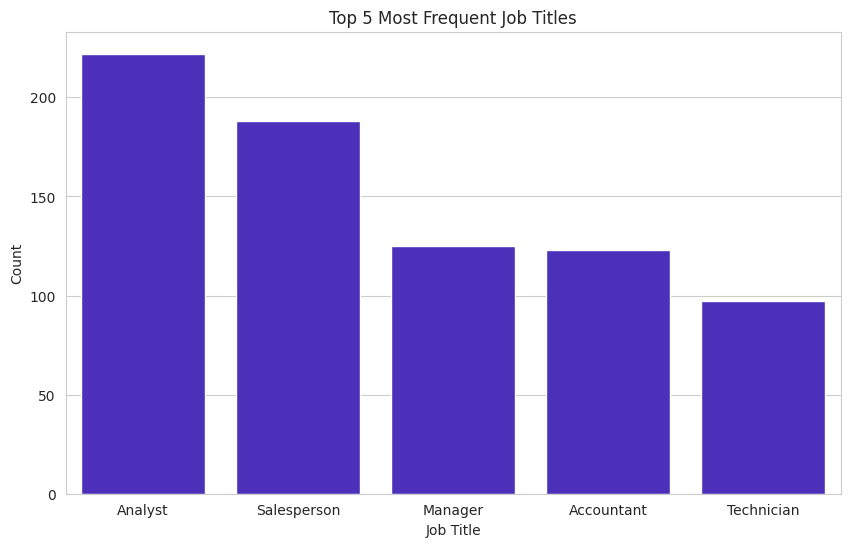

In [252]:
plt.figure(figsize=(10, 6))

sns.barplot(y=top_5.values, x=top_5.index,  color="#4019D1")

plt.title('Top 5 Most Frequent Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')

plt.show()

There are 43 job titles, the most common being "Analyst" and "Salesperson".

What are the highest average salaries for jobs?

In [253]:
top_salaries = df.groupby("job_title")["Salary"].mean().sort_values(ascending=False).head()
top_salaries

,Salary
job_title,
CEO,9312.500000
Developer,8357.142857
Doctor,8000.000000
Engineer,7291.900000
Electrician,6513.636364


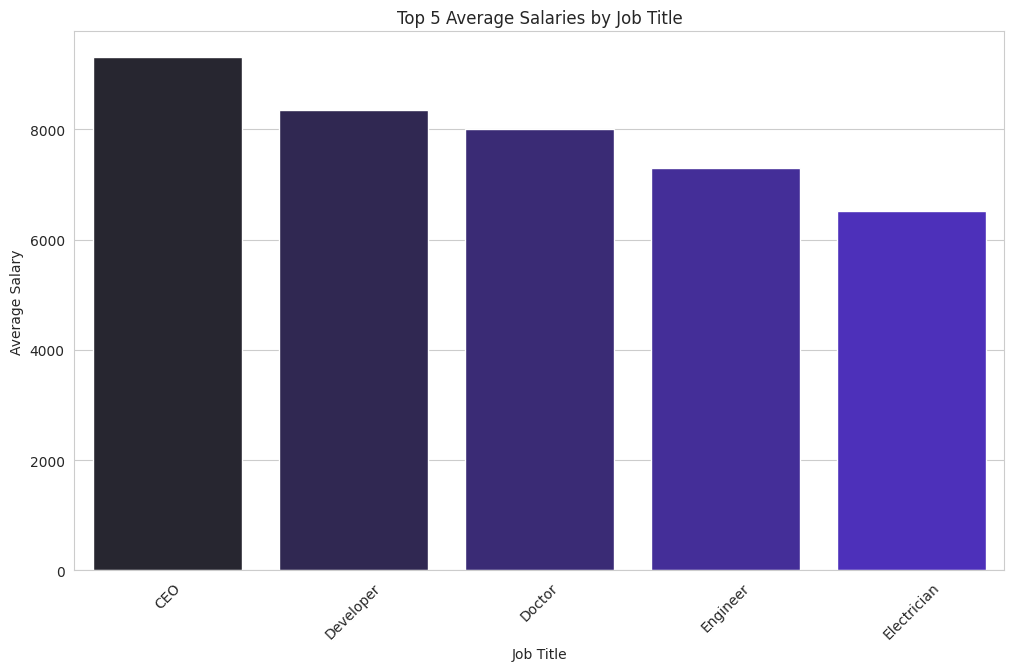

In [254]:
plt.figure(figsize=(12, 7))
top_jobs = df.groupby('job_title')['Salary'].mean().nlargest(5)
custom_palette = sns.dark_palette("#4019D1", n_colors=5)

sns.barplot(
    x=top_jobs.index,
    y=top_jobs.values,
    hue=top_jobs.index,
    palette=custom_palette,
    legend=False
)
plt.title("Top 5 Average Salaries by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)
plt.show()

Highest average CEO salary **But !**

### <font color='red'> The result is illogical; the average CEO salary is approximately 9500 SAR, which suggests either data entry errors or misclassified roles. </font>

In [255]:
df[df['job_title'] == 'CEO']

,job_title,comp_size,region,benefits,contract,exper,gender,Salary,year,month
667,CEO,SB,Makkah,0,1,10,2,15000.0,2022,12
671,CEO,L,Eastern,0,1,0,0,10250.0,2022,12
993,CEO,SB,Makkah,0,1,2,2,6000.0,2022,12
1082,CEO,SB,Makkah,0,1,2,2,6000.0,2023,1


In [256]:
df.loc[[993, 1082], 'job_title'] = 'Manager'

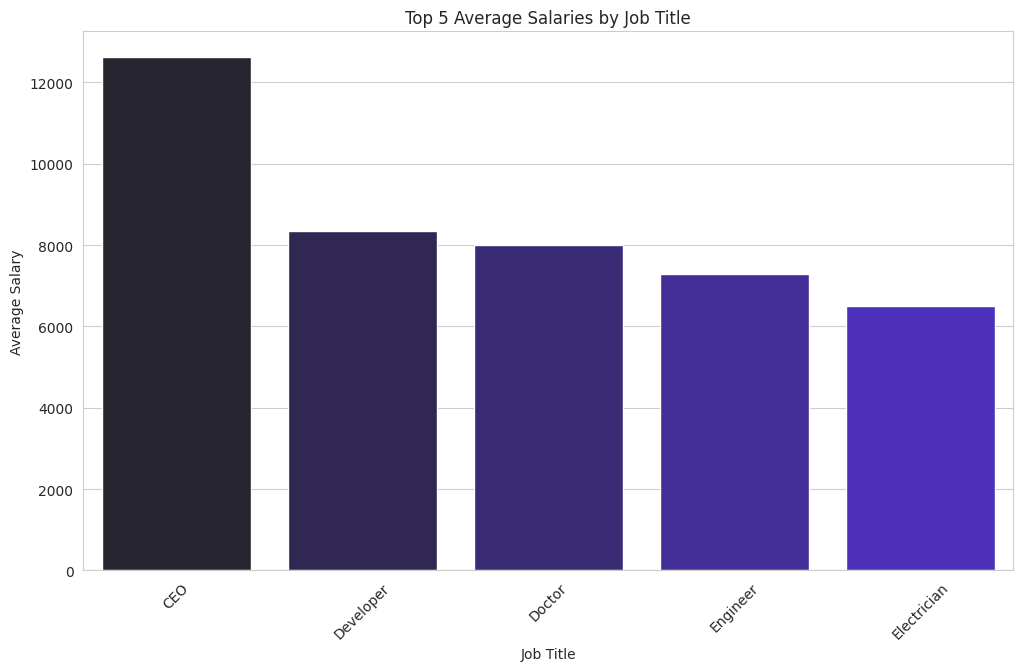

In [257]:
plt.figure(figsize=(12, 7))
top_jobs = df.groupby('job_title')['Salary'].mean().nlargest(5)
custom_palette = sns.dark_palette("#4019D1", n_colors=5)

sns.barplot(
    x=top_jobs.index,
    y=top_jobs.values,
    hue=top_jobs.index,
    palette=custom_palette,
    legend=False
)
plt.title("Top 5 Average Salaries by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)
plt.show()

The CEO salary data is **consistent and logical** when cross-referenced with experience and company size:

* **Case 1:** A salary of **15,000 SAR** is realistic for **10 years of experience** in a small company (**SB**).
* **Case 2:** A salary of **10,250 SAR** in a **Large (L)** company is justified by the **0 years of experience** requirement.
* **Cases 3 & 4:** There was an error in job classification; he changed his title from CEO to Manager.

<font color='green'>**Conclusion:** The results are realistic; the salary levels directly correlate with the required years of experience and the specific scale of the business.</font>



---



Which region has the most jobs?

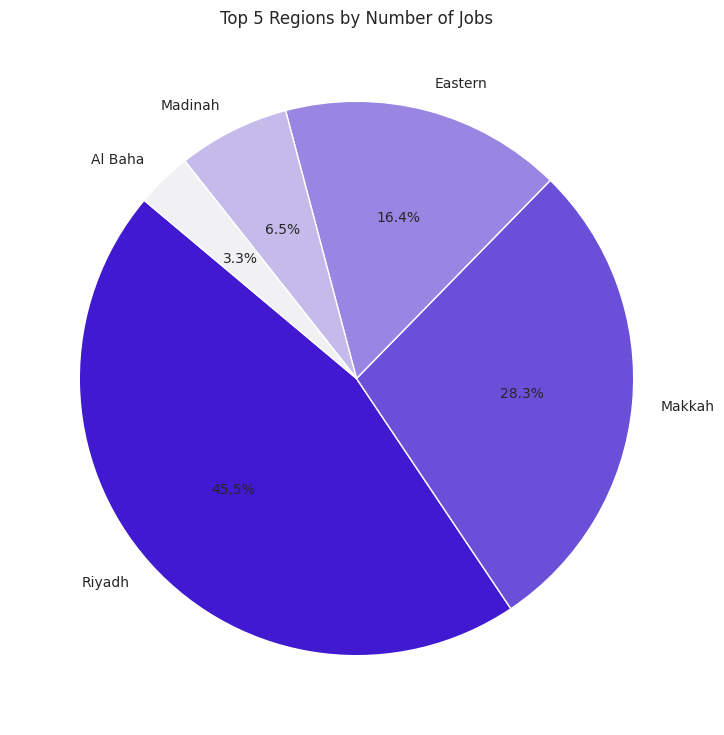

In [258]:
top_regions = df['region'].value_counts().head()

plt.figure(figsize=(9, 9))

custom_palette = sns.light_palette("#4019D1", n_colors=5, reverse=True)

plt.pie(top_regions.values, labels=top_regions.index, colors=custom_palette,
        autopct='%1.1f%%', startangle=140 )

plt.title('Top 5 Regions by Number of Jobs')

plt.show()

Riyadh has the most, at 45%.



---



Available jobs vary by gender and contract type (remote or full-time).

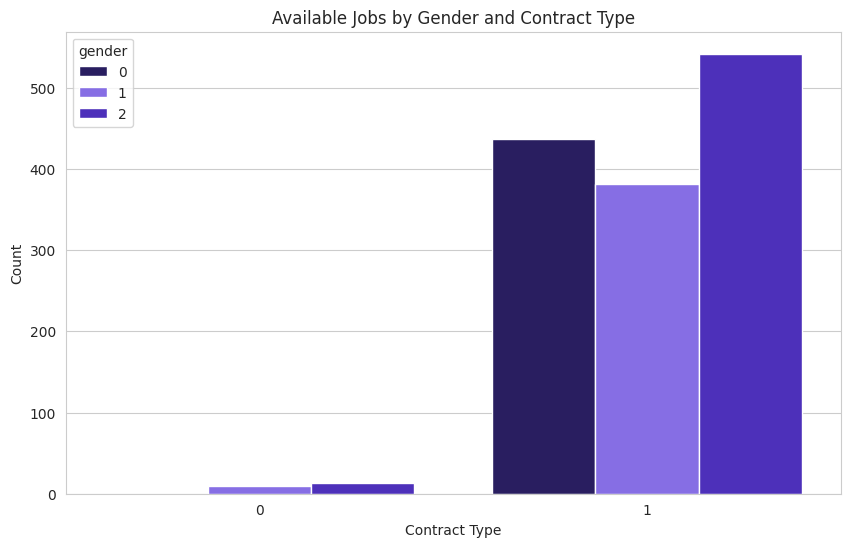

In [259]:
plt.figure(figsize=(10, 6))
sns.countplot(x="contract", hue="gender", data=df, palette=["#21136B", "#7A5AF8" ,"#4019D1"])
plt.title('Available Jobs by Gender and Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

 - 0 - Male, 1 - Female, 2 - Both.
- 1 - Full-time, 0 - Remote



---



Which year has the highest number of job vacancies?

In [260]:
my_colors = ["#21136B", "#7A5AF8", "#4019D1"]

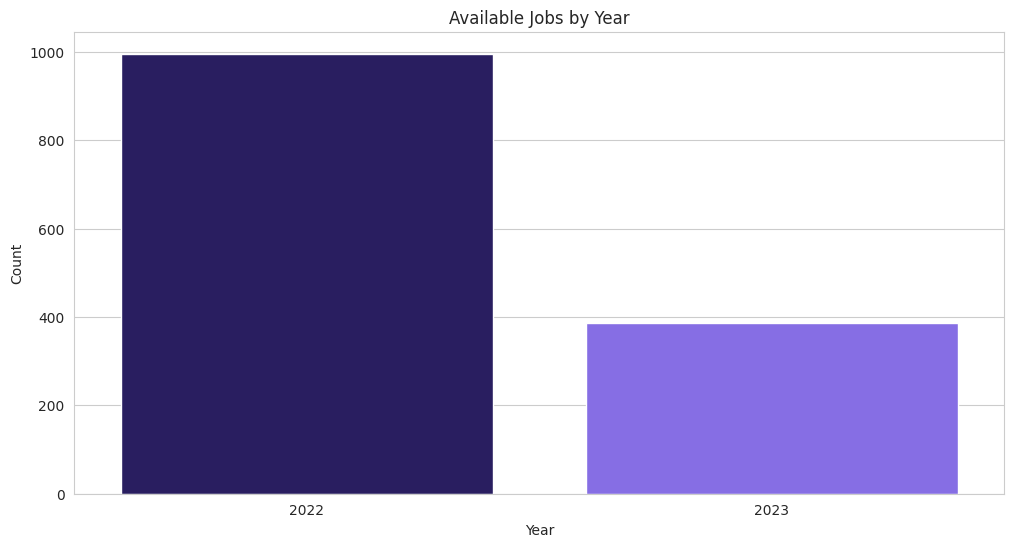

In [261]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="year",
    hue="year",
    palette=my_colors[:df['year'].nunique()],
    legend=False
)
plt.title("Available Jobs by Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

In [262]:
print(df[df['year'] == 2022].groupby('month').groups.keys())
print(df[df['year'] == 2023].groupby('month').groups.keys())

dict_keys([10, 11, 12])
dict_keys([1])


2022.

The dataset represents only 2022, including January 2023 as a direct continuation of the 2022 vacancy cycle.



---



Top month job postings

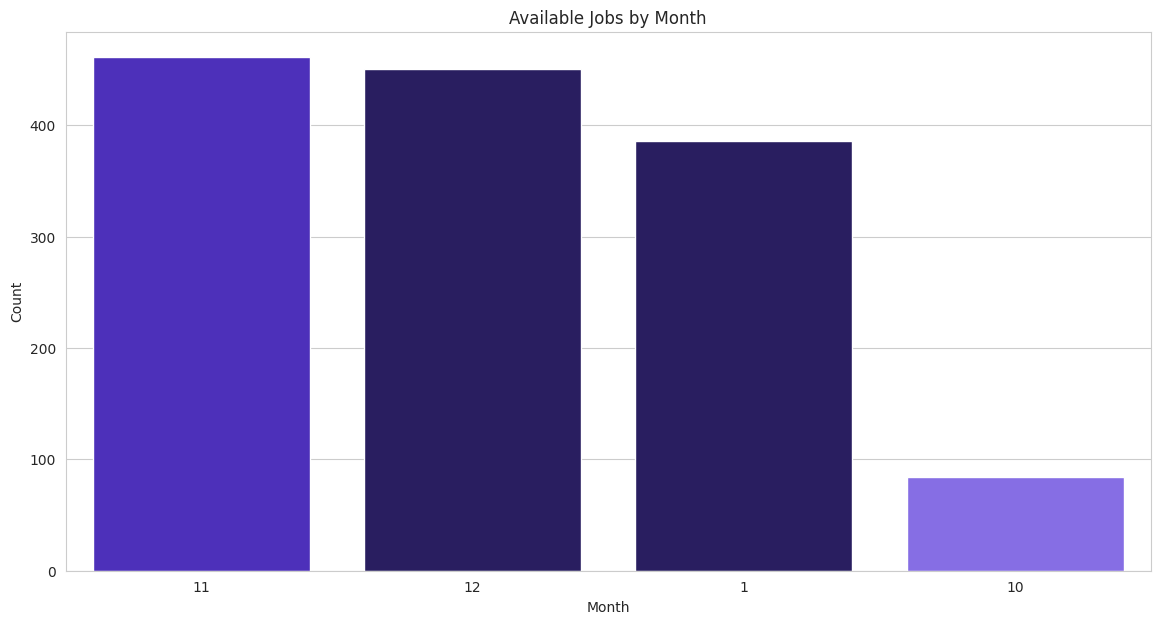

In [263]:
plt.figure(figsize=(14, 7))

num_months = df['month'].nunique()
sns.countplot(
    data=df,
    x='month',
    hue='month',
    order=df['month'].value_counts().index,
    palette=sns.color_palette(my_colors, n_colors=num_months),
    legend=False
)
plt.title('Available Jobs by Month')
plt.xlabel('Month')
plt.ylabel('Count')

plt.show()

Month 11



---



What are the most common job openings based on company size?

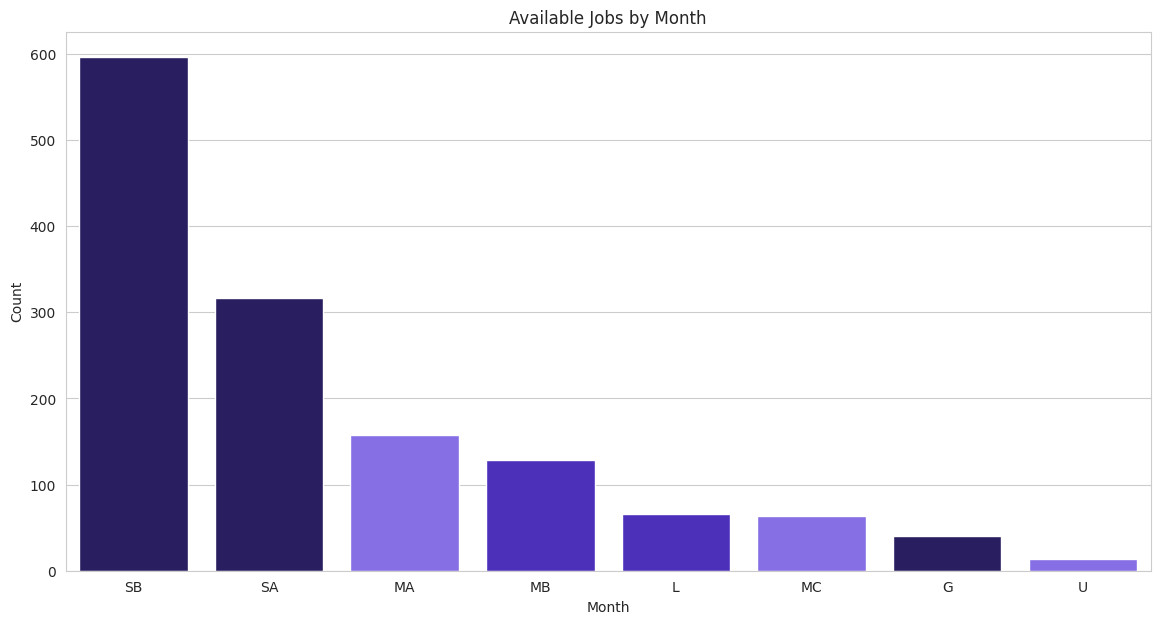

In [264]:
plt.figure(figsize=(14, 7))

num_months = df['comp_size'].nunique()
sns.countplot(
    data=df,
    x='comp_size',
    hue='comp_size',
    order=df['comp_size'].value_counts().index,
    palette=sns.color_palette(my_colors, n_colors=num_months),
    legend=False
)
plt.title('Available Jobs by Month')
plt.xlabel('Month')
plt.ylabel('Count')

plt.show()

Most jobs are small business

comp_size	MA, MB, MC, etc.	Indicates the company size: MA - Medium A, SB - Small B, etc.



---



Jobs by Benefits

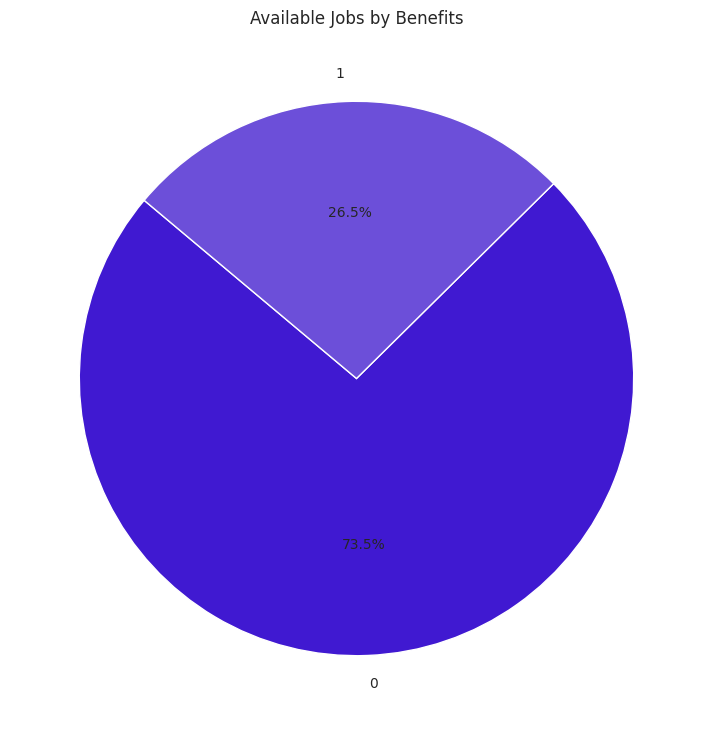

In [265]:
top_regions = df['benefits'].value_counts().head()

plt.figure(figsize=(9, 9))

custom_palette = sns.light_palette("#4019D1", n_colors=5, reverse=True)

plt.pie(top_regions.values, labels=top_regions.index, colors=custom_palette,
        autopct='%1.1f%%', startangle=140 )

plt.title('Available Jobs by Benefits')

plt.show()

1 - Benefits offered, 0 - No benefits.



---



Data preparation for the model

Heat map

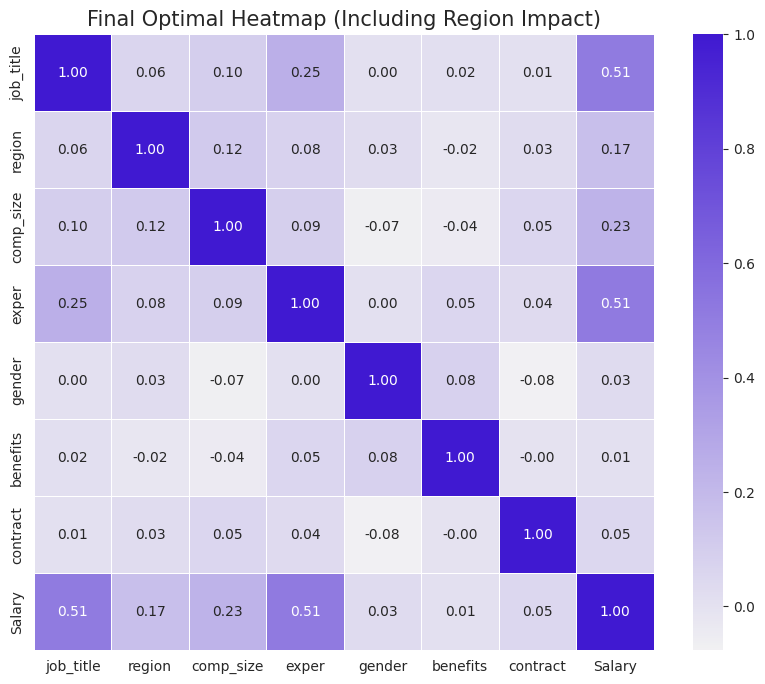

In [266]:
df_opt = df.copy()

df_opt['job_title'] = df_opt.groupby('job_title')['Salary'].transform('mean')
df_opt['region'] = df_opt.groupby('region')['Salary'].transform('mean')

size_map = {'SA':1, 'SB':2, 'MA':3, 'MB':4, 'MC':5, 'L':6, 'G':7, 'U':8}
df_opt['comp_size'] = df_opt['comp_size'].map(size_map)

features = ['job_title', 'region', 'comp_size', 'exper', 'gender', 'benefits', 'contract', 'Salary']
corr = df_opt[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=sns.light_palette("#4019D1", as_cmap=True),
    linewidths=0.5
)

plt.title("Final Optimal Heatmap (Including Region Impact)", fontsize=15)
plt.show()

The strongest correlation in the heat map is between experience and job title.



---



After reviewing the heat map, we removed the least correlated factors.

In [267]:
df_opt.drop(columns=["gender"], inplace=True)
df_opt.drop(columns=["benefits"], inplace=True)
df_opt.drop(columns=["contract"], inplace=True)
df_opt.drop(columns=["year"], inplace=True)
df_opt.drop(columns=["month"], inplace=True)

In [268]:
df_opt

,job_title,comp_size,region,exper,Salary
0,4635.787234,2,5256.135266,0,4000.0
1,4450.861702,2,5023.747191,0,4000.0
2,4143.370968,3,5023.747191,4,4000.0
3,4897.284553,4,5276.804538,0,4000.0
4,4635.787234,1,5023.747191,2,5000.0
...,...,...,...,...,...
1465,5497.333333,2,5276.804538,4,4000.0
1466,4450.861702,2,6455.444444,2,4000.0
1467,5478.300000,2,5276.804538,0,4500.0
1468,5024.137931,4,5256.135266,4,4200.0


This final data format for predicting salaries and the type of data used is regression.



---



actual chart

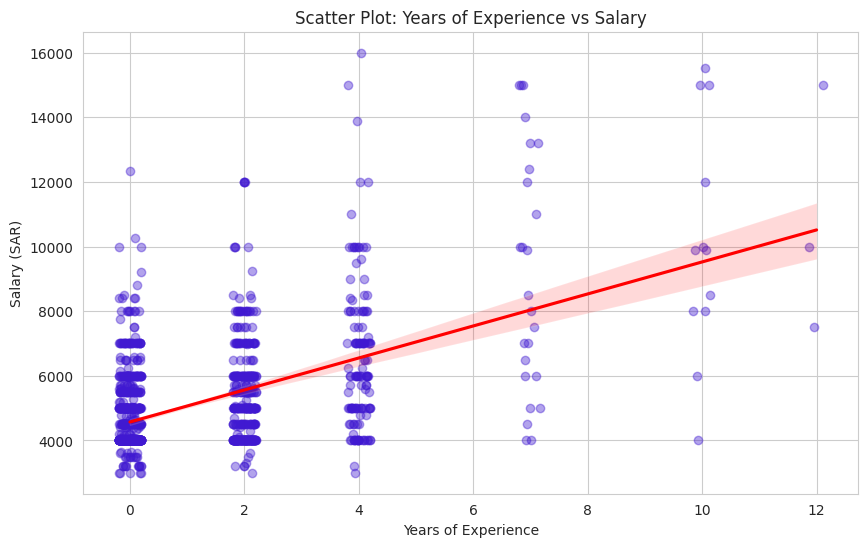

In [269]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df_opt, x='exper', y='Salary',
            scatter_kws={'alpha':0.4, 'color':'#4019D1'},
            line_kws={'color':'red'},
            x_jitter=0.2)

plt.title('Scatter Plot: Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary (SAR)')

plt.show()

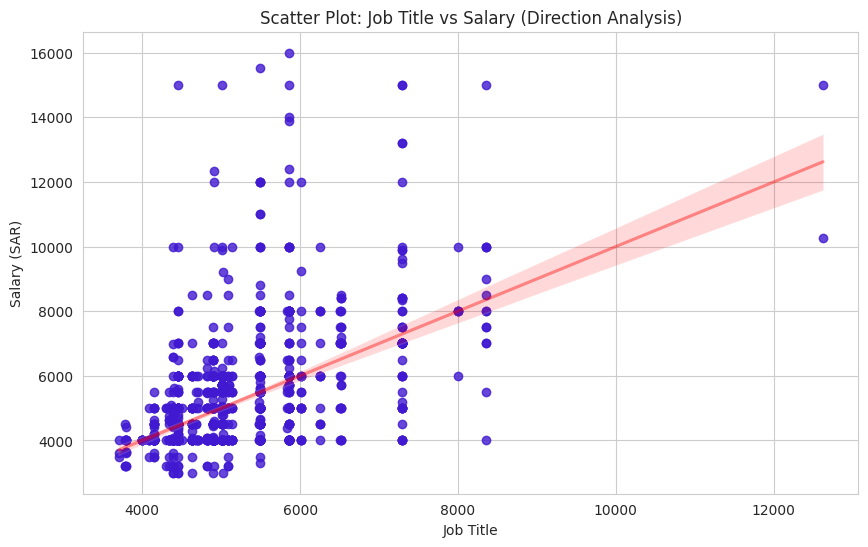

In [270]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df_opt, x='job_title', y='Salary',
            scatter_kws={ 'color':'#4019D1'},
            line_kws={'alpha':0.4,'color':'red'},
            x_jitter=0.2)

plt.title('Scatter Plot: Job Title vs Salary (Direction Analysis)')
plt.xlabel('Job Title')
plt.ylabel('Salary (SAR)')

plt.show()

#Data Preparation Conclusion
Status: Analyzed & Visualized
The data cleaning and exploratory phase is now complete.

Data Cleaning: Handled duplicates, missing values, and outliers.

Data Analysis: Key features affecting salary have been identified.

Visualization: Data distributions and correlations are verified.

Final Note: The dataset is fully prepared for the Salary Prediction modeling phase.